In [1]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('../../../data/train_text_with_perplexities.csv')
df_val = pd.read_csv('../../../data/val_text_with_perplexities.csv')
df_test = pd.read_csv('../../../data/test_text_with_perplexities.csv')
# df.sample(5)

In [2]:
#train
agg_method = "mean"
df_train.sort_values(['filename','part','position'],inplace=True)
df_grouped_train = df_train.groupby(['filename','part'],as_index=False).agg({
    'per_pt_model': agg_method,
    'per_hc_model': agg_method,
    'scz':'first'
})
df_grouped_train.sort_values(['filename','part'],inplace=True)
df_grouped_train = df_grouped_train.groupby(['filename']).agg({
    'per_pt_model':lambda x: list(x),
    'per_hc_model':lambda x: list(x),
    'scz':'first'
})
#validation
df_val.sort_values(['filename','part','position'],inplace=True)
df_grouped_val = df_val.groupby(['filename','part'],as_index=False).agg({
    'per_pt_model': agg_method,
    'per_hc_model': agg_method,
    'scz':'first'
})
df_grouped_val.sort_values(['filename','part'],inplace=True)
df_grouped_val = df_grouped_val.groupby(['filename']).agg({
    'per_pt_model':lambda x: list(x),
    'per_hc_model':lambda x: list(x),
    'scz':'first'
})
#test
df_test.sort_values(['filename','part','position'],inplace=True)
df_grouped_test = df_test.groupby(['filename','part'],as_index=False).agg({
    'per_pt_model': agg_method,
    'per_hc_model': agg_method,
    'scz':'first'
})
df_grouped_test.sort_values(['filename','part'],inplace=True)
df_grouped_test = df_grouped_test.groupby(['filename']).agg({
    'per_pt_model':lambda x: list(x),
    'per_hc_model':lambda x: list(x),
    'scz':'first'
})



In [3]:


X_train = df_grouped_train[['per_pt_model','per_hc_model']].apply(lambda x: np.concat([x['per_pt_model'],x['per_hc_model']]), axis=1).to_list()
y_train = df_grouped_train['scz'].to_list()

X_val = df_grouped_val[['per_pt_model','per_hc_model']].apply(lambda x: np.concat([x['per_pt_model'],x['per_hc_model']]), axis=1).to_list()
y_val = df_grouped_val['scz'].to_list()

X_test = df_grouped_test[['per_pt_model','per_hc_model']].apply(lambda x: np.concat([x['per_pt_model'],x['per_hc_model']]), axis=1).to_list()
y_test = df_grouped_test['scz'].to_list()

In [4]:
print(f"Train:\n{pd.Series(y_train).value_counts()}\n\nValidation:\n{pd.Series(y_val).value_counts()}\n\nTest:\n{pd.Series(y_test).value_counts()} ")

Train:
1    109
0     61
Name: count, dtype: int64

Validation:
1    14
0     9
Name: count, dtype: int64

Test:
1    13
0     7
Name: count, dtype: int64 


In [5]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=128)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train, y_train)

In [6]:
print(f"Before oversampling:\n\n {pd.Series(y_train).value_counts()}\n\n")
print(f"After oversampling:\n\n {pd.Series(y_train_bal).value_counts()}\n\n")

Before oversampling:

 1    109
0     61
Name: count, dtype: int64


After oversampling:

 0    109
1    109
Name: count, dtype: int64




In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mlp =MLPClassifier([100,50,20],max_iter=2000,learning_rate= "adaptive",random_state=123)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", mlp),
])
pipe.fit(X_train_bal, y_train_bal)

# Evalua
train_score = pipe.score(X_train_bal, y_train_bal)
val_score = pipe.score(X_val, y_val)
print(f"Train: {train_score:.3f}, Val: {val_score:.3f}")

Train: 1.000, Val: 0.783


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score,RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

y_test_pred = pipe.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.92      0.85      0.88        13

    accuracy                           0.85        20
   macro avg       0.83      0.85      0.84        20
weighted avg       0.86      0.85      0.85        20



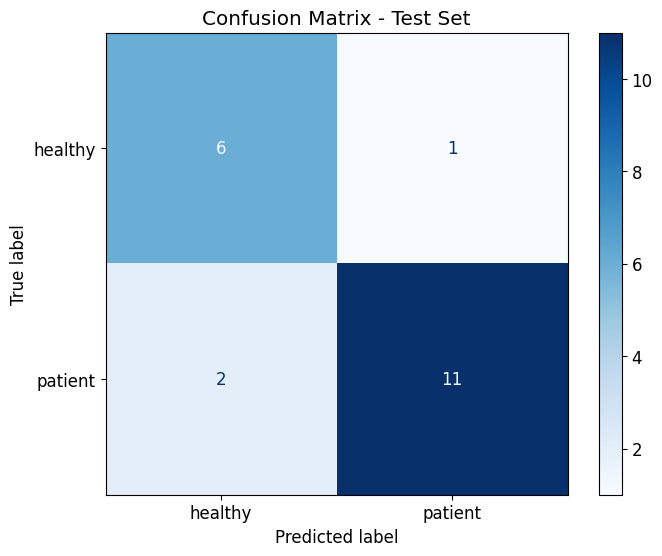

In [9]:
# Confusion Matrix

labels_order = ["healthy", "patient"]
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_order)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix - Test Set')
plt.show()

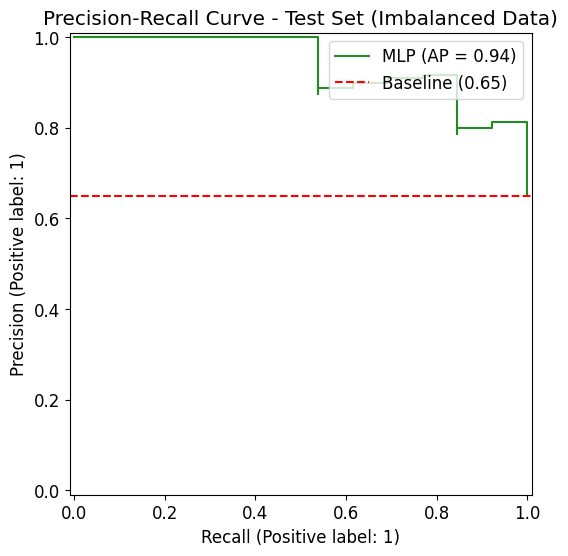

Average Precision (AP): 0.941


c:\Universidad\1\Universidad\TFG\TFG\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


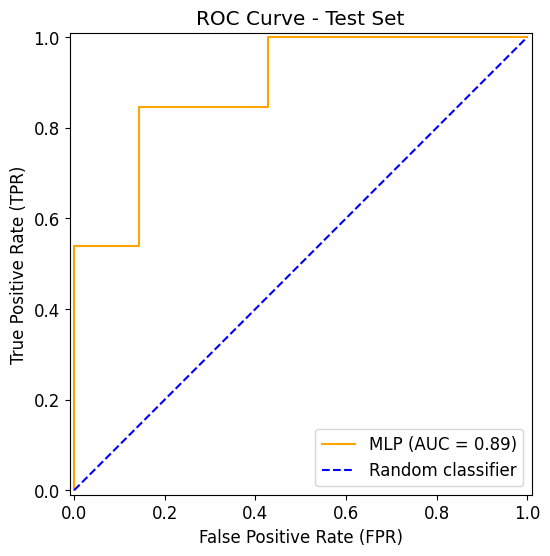

AUC-ROC: 0.890


In [10]:
import pickle

y_test_proba = pipe.predict_proba(X_test)[:, 1]
with open("./temp_data/mlp_mean.pkl", "wb") as f:
    pickle.dump(y_test_proba, f)
ap_score = average_precision_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=f"MLP",
    ax=ax,
    color="forestgreen", 
)

baseline = sum(y_test) / len(y_test)
ax.axhline(baseline, linestyle="--", color="red", label=f"Baseline ({baseline:.2f})")

ax.set_title("Precision-Recall Curve - Test Set (Imbalanced Data)")
ax.legend(loc="upper right")
plt.show()

print(f"Average Precision (AP): {ap_score:.3f}")


roc_auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=f"MLP",
    ax=ax,
    color="orange",  
)

ax.plot([0, 1], [0, 1], linestyle="--", color="blue", label="Random classifier")

ax.set_title("ROC Curve - Test Set")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.legend(loc="lower right")
plt.show()

print(f"AUC-ROC: {roc_auc:.3f}")
